# **CUSTOMER CHURN ANALYSIS FOR A TELCO COMPANY**

## **Importing Data & Sanity Checks**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Summary stats
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Churn distribution
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


## **DATA CLEANING**

In [7]:
# Changing data type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
# Drop rows where Null
df.dropna(subset=["TotalCharges"], inplace=True)
print(df.shape)

(7032, 21)


In [9]:
# Drop customer id column
df.drop(columns=["customerID"], inplace=True)

In [10]:
# Convert churn to binary
df["Churn"] = (df["Churn"] == "Yes").astype(int)
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [11]:
# Sanity check
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## **EXPLORATORY DATA ANALYSIS**

**Plot 1 — Churn Distribution:**

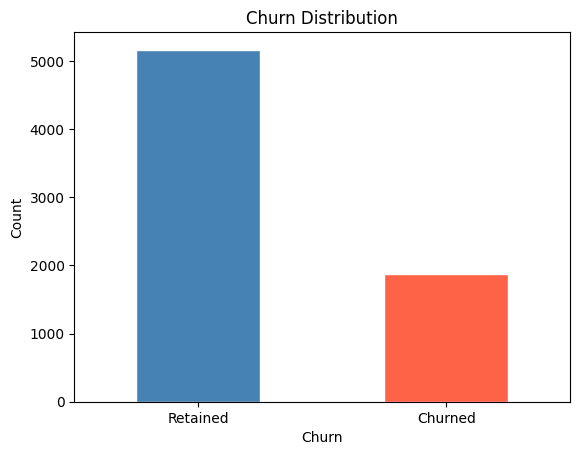

In [12]:
df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], edgecolor="white")
plt.title("Churn Distribution")
plt.xticks([0, 1], ["Retained", "Churned"], rotation=0)
plt.ylabel("Count")
plt.show()

The dataset is imbalanced — about 73% of customers were retained and 27% churned.
This matters because a model trained on imbalanced data tends to just predict
"No Churn" for everything and still appear ~73% accurate. We'll need to handle
this later using SMOTE or class weights.

**Plot 2 — Tenure vs Churn:**

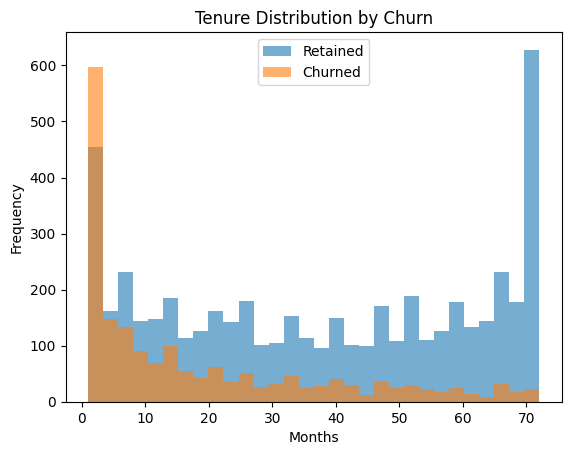

In [13]:
df.groupby("Churn")["tenure"].plot(kind="hist", bins=30, alpha=0.6, legend=True)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Months")
plt.legend(["Retained", "Churned"])
plt.show()

Customers who churn tend to have very low tenure (0–12 months), meaning most
churn happens early in the customer lifecycle. Retained customers are spread
more evenly across all tenure values. This suggests that the first year is the
most critical window for churn prevention — targeting new customers with
retention offers could be highly effective.

**Plot 3 — Monthly Charges vs Churn:**

/tmp/ipykernel_1168/4195685868.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["steelblue", "tomato"])


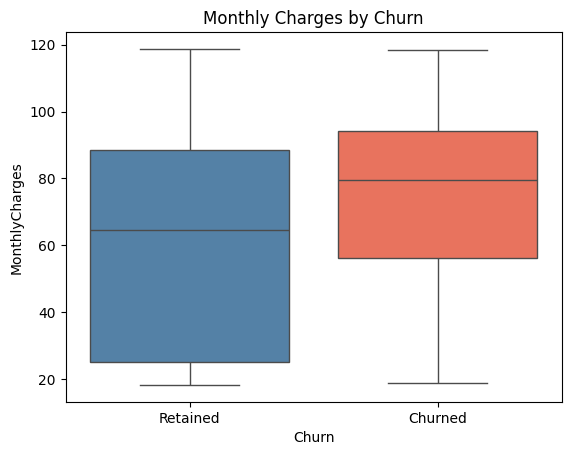

In [14]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["steelblue", "tomato"])
plt.xticks([0, 1], ["Retained", "Churned"])
plt.title("Monthly Charges by Churn")
plt.show()

Churned customers have noticeably higher monthly charges than retained ones.
This suggests that customers on expensive plans are more likely to leave,
possibly due to perceived lack of value. Offering discounts or plan
downgrades to high-paying at-risk customers could be a useful retention strategy.

**Plot 4 — Churn rate by Contract Type:**

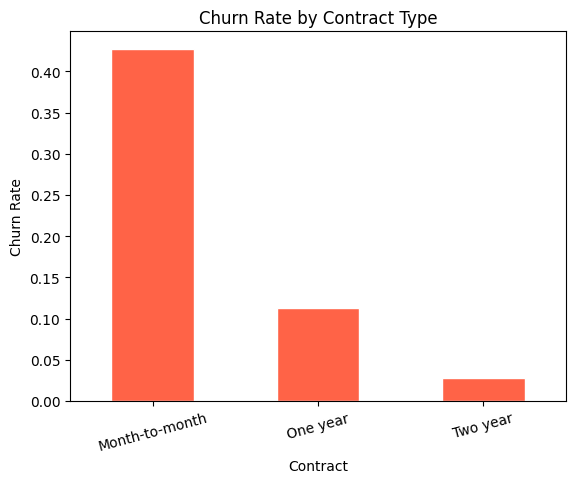

In [15]:
df.groupby("Contract")["Churn"].mean().sort_values(ascending=False).plot(
    kind="bar", color="tomato", edgecolor="white")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.show()

Month-to-month contract customers churn at a dramatically higher rate (approx 43%) compared to one year (approx 11%) and two-year (approx 3%) contract customers. This is one
of the strongest predictors of churn in the dataset. Customers without long-term
commitment have little friction to leave. Encouraging customers to upgrade to
annual contracts should be a key business priority.

**Plot 5 — Correlation Heatmap:**

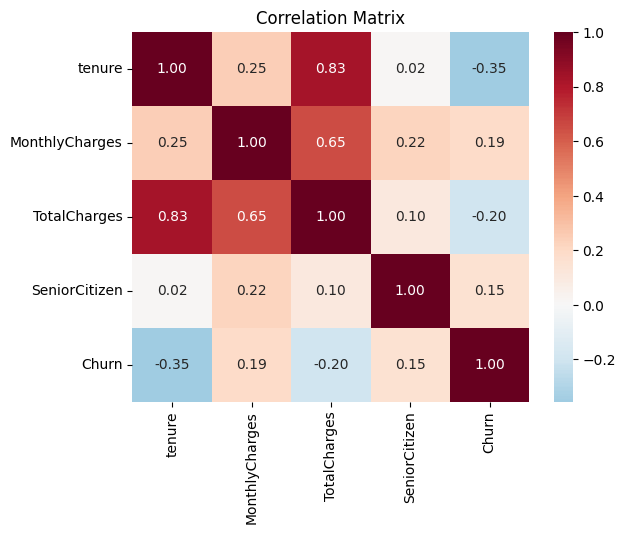

In [16]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Matrix")
plt.show()

Tenure has a strong negative correlation with Churn (-0.35) — longer-tenured
customers are much less likely to churn. Monthly Charges has a mild positive
correlation with Churn (+0.19) — higher bills slightly increase churn risk.
TotalCharges is highly correlated with Tenure (+0.83), which is expected since
total charges naturally accumulate over time. To avoid multicollinearity in our
model, we'll engineer a smarter feature from these two in the next step.

## **FEATURE ENGINEERING**

**Part 1 — Encode binary Yes/No columns:**

In [17]:
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)

df["gender"] = (df["gender"] == "Male").astype(int)

**Part 2 — Encode "No internet/phone service" columns:**

In [18]:
no_service_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup",
                   "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

for col in no_service_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0,
                           "No internet service": 0,
                           "No phone service": 0})

**Part 3 — Encode multi-category columns:**

In [19]:
from sklearn.preprocessing import LabelEncoder

for col in ["InternetService", "Contract", "PaymentMethod"]:
    df[col] = LabelEncoder().fit_transform(df[col])

**Part 4 — Engineer 2 new features:**

In [20]:
# How much a customer pays per month on average
df["ChargePerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)

# Group tenure into buckets: 0-12, 12-24, 24-48, 48-72 months
df["TenureBucket"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72],
                             labels=[0, 1, 2, 3]).astype(int)

In [21]:
df.head()
df.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


## **TRAIN/TEST SPLIT & HANDLING IMBALANCE**

**Split features and target:**

In [22]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 21)
Target shape: (7032,)


**Train/Test split:**

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5625, 21)
Test size: (1407, 21)


**Handle imbalance using SMOTE:**

In [24]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {0: 4130, 1: 4130}


**Scale the features:**

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

## **Training the Models**

**1. Logistic Regression (baseline model)**

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_sc, y_train_sm)
print("✅ Logistic Regression trained")

✅ Logistic Regression trained


**2. Random Forest**

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
print("✅ Random Forest trained")

✅ Random Forest trained


## **Evaluating the Models**

**Predictions**

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Logistic Regression
lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

# Random Forest
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

**Classification Report**

In [29]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, target_names=["Retained", "Churned"]))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=["Retained", "Churned"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Retained       0.86      0.78      0.82      1033
     Churned       0.52      0.66      0.58       374

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.75      0.76      1407

=== Random Forest ===
              precision    recall  f1-score   support

    Retained       0.85      0.82      0.84      1033
     Churned       0.55      0.61      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.77      0.77      1407



**AUC-ROC Score**

In [30]:
print("Logistic Regression AUC:", round(roc_auc_score(y_test, lr_proba), 4))
print("Random Forest AUC:       ", round(roc_auc_score(y_test, rf_proba), 4))

Logistic Regression AUC: 0.8136
Random Forest AUC:        0.8108


**ROC Curve**

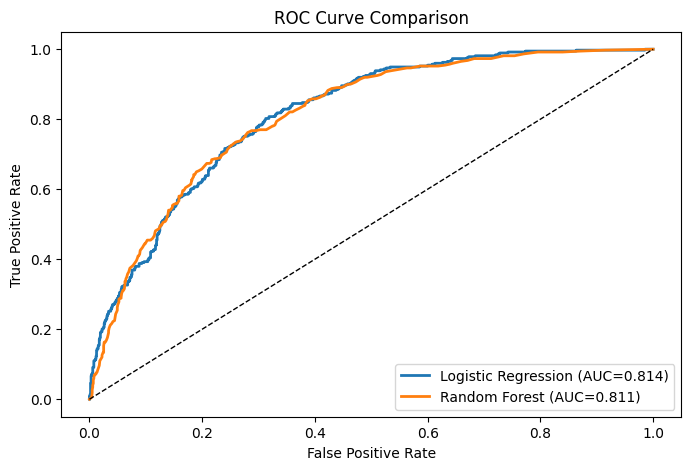

In [31]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 5))

for name, proba in [("Logistic Regression", lr_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1], [0,1], "k--", lw=1)
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

## **Feature Importance**

**Logistic Regression Coefficients**

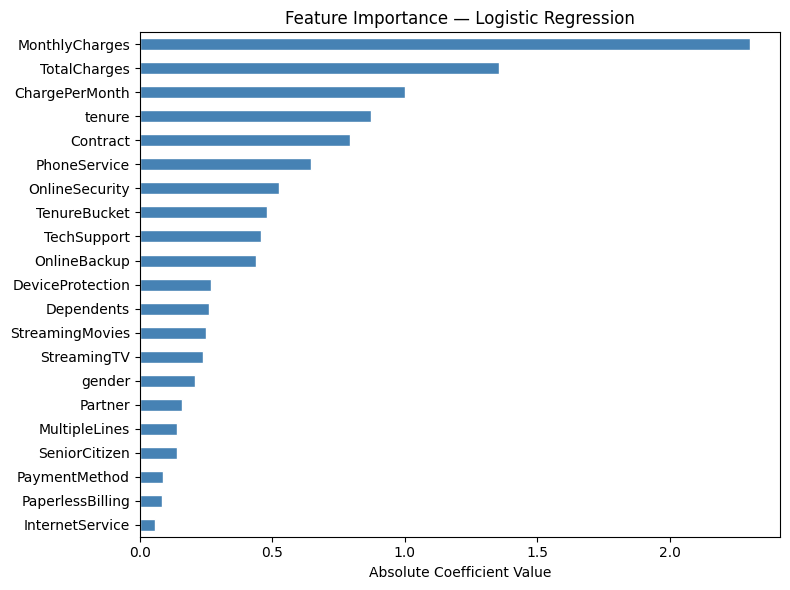

In [32]:
importance_lr = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
importance_lr = importance_lr.sort_values(ascending=True)

importance_lr.plot(kind="barh", figsize=(8, 6), color="steelblue", edgecolor="white")
plt.title("Feature Importance — Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()

**Random Forest Feature Importance**

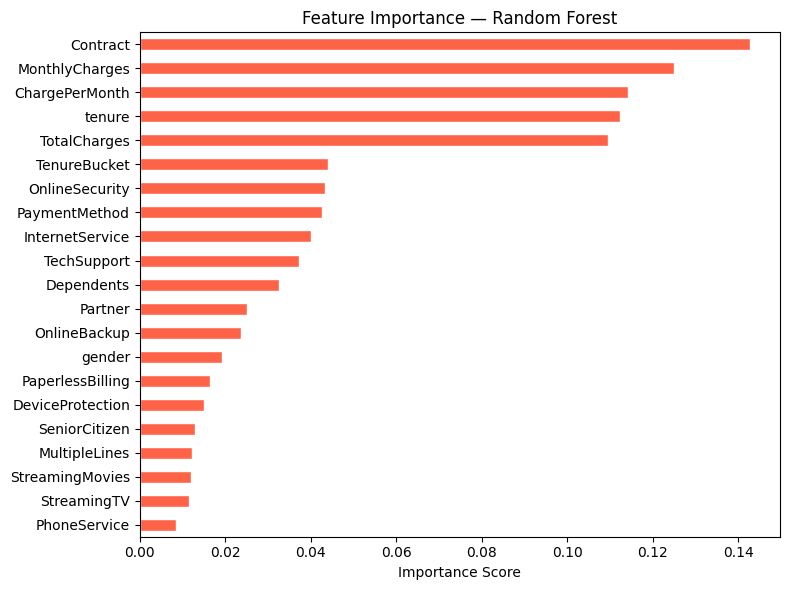

In [33]:
importance_rf = pd.Series(rf.feature_importances_, index=X.columns)
importance_rf = importance_rf.sort_values(ascending=True)

importance_rf.plot(kind="barh", figsize=(8, 6), color="tomato", edgecolor="white")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

**Compare top 5 features from both**

In [34]:
top_lr = importance_lr.sort_values(ascending=False).head(5)
top_rf = importance_rf.sort_values(ascending=False).head(5)

print("=== Top 5 — Logistic Regression ===")
print(top_lr)
print("\n=== Top 5 — Random Forest ===")
print(top_rf)

=== Top 5 — Logistic Regression ===
MonthlyCharges    2.301659
TotalCharges      1.355870
ChargePerMonth    1.001286
tenure            0.874129
Contract          0.794178
dtype: float64

=== Top 5 — Random Forest ===
Contract          0.142638
MonthlyCharges    0.124895
ChargePerMonth    0.114125
tenure            0.112423
TotalCharges      0.109600
dtype: float64


In [35]:
df.to_csv("churn_clean.csv", index=False)

from google.colab import files
files.download("churn_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
print(df["gender"].value_counts())
print(df["gender"].unique())

gender
1    3549
0    3483
Name: count, dtype: int64
[0 1]


In [37]:
print(df[["gender", "PaperlessBilling", "Dependents", "Partner"]].value_counts())

gender  PaperlessBilling  Dependents  Partner
0       1                 0           0          1029
1       1                 0           0           972
        0                 0           0           653
0       0                 0           0           626
1       1                 0           1           574
0       1                 0           1           523
                          1           1           455
1       1                 1           1           435
        0                 1           1           427
0       0                 1           1           423
                          0           1           282
1       0                 0           1           274
                          1           0           112
        1                 1           0           102
0       1                 1           0            78
        0                 1           0            67
Name: count, dtype: int64


In [38]:
# Verify all columns look correct
print(df["gender"].value_counts())
print(df["PaperlessBilling"].value_counts())
print(df["Dependents"].value_counts())

# Re-export fresh
df.to_csv("churn_clean.csv", index=False)

from google.colab import files
files.download("churn_clean.csv")

gender
1    3549
0    3483
Name: count, dtype: int64
PaperlessBilling
1    4168
0    2864
Name: count, dtype: int64
Dependents
0    4933
1    2099
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>